# Water Demand Forecasting — Baseline → Better → Optimal

**Real dataset:** Siemens/KIT hourly water-demand data (Zenodo DOI `10.5281/zenodo.11045013`).  
**Selected before locked test:** `voting_regressor`  
**Locked-test MAE:** `158.251` | **RMSE:** `220.992` | **R²:** `0.9588`

This notebook is generated only after the actual experiments finish. No metric below is fabricated.


## Methodology rules

- Chronological train/validation/test split; no shuffled forecasting CV.
- OHE only for nominal features; ordinal encoding only for a genuinely ordered rain-intensity feature; binary indicators remain 0/1.
- Yeo-Johnson is applied inside the training-fitted scale-sensitive numerical pipeline, followed by RobustScaler.
- Tree/boosting models do not receive scaling merely for appearance.
- Target rolling features are computed after `shift(1)`.
- Optuna and Keras Tuner never see the locked test.


In [1]:
# Colab/local setup: clone the repository first if running outside it.
from pathlib import Path
import json, pandas as pd
ROOT = Path.cwd()
if not (ROOT / 'artifacts/results/experiment_summary.json').exists():
    print('Run this notebook from the repository root after cloning the project.')
summary = json.loads((ROOT / 'artifacts/results/experiment_summary.json').read_text())
summary['dataset']['source'], summary['split']


('Hourly Water Demand of a Mixed District Recorded by Supplier',
 {'rows': 45864,
  'train_rows': 32104,
  'validation_rows': 6880,
  'test_rows': 6880,
  'train_end': '2019-09-06T15:00:00',
  'validation_start': '2019-09-06T16:00:00',
  'validation_end': '2020-06-19T07:00:00',
  'test_start': '2020-06-19T08:00:00',
  'test_end': '2021-04-01T23:00:00'})

## Dataset audit

In [2]:
pd.DataFrame({
    'raw_missing': summary['dataset']['audit']['raw_missing'],
    'canonical_missing': summary['dataset']['audit']['canonical_missing'],
}).fillna(0)


,raw_missing,canonical_missing
Date,0.0,0
Time,0.0,0
Consumption,509.0,0
Temperature,0.0,0
Rain,25.0,25
Sun,0.0,0
timestamp,0.0,0


## Feature engineering and preprocessing
The complete executable implementation is in `src/forecasting_pipeline.py`. The code below shows the actual feature policy used.

In [3]:
summary['feature_policy']


{'nominal_encoding': 'OneHotEncoder',
 'ordinal_encoding': 'OrdinalEncoder only for rain_intensity: none < light < moderate < heavy',
 'binary_encoding': '0/1',
 'scale_sensitive_numeric': 'MedianImputer -> YeoJohnson -> RobustScaler',
 'trees': 'No unnecessary scaling/Yeo-Johnson requirement; train-only imputation + categorical encoding',
 'target_history': 'all lags/rolls are past-only; rolling uses target.shift(1)'}

## Baseline validation

In [4]:
baseline = pd.read_csv(ROOT / 'artifacts/results/baseline_models/metrics.csv')
baseline


,model,mae,rmse,r2,smape_pct
0,random_forest_baseline,153.045601,212.873636,0.956750,9.207670
1,ridge_yj_robust,190.398474,256.712187,0.937102,11.385796
2,naive_lag_168,276.005814,402.751123,0.845184,15.003604
3,naive_lag_24,291.239826,427.055847,0.825935,16.203529
4,naive_lag_1,336.087936,454.725201,0.802649,19.777050


## Better: Bagging + Boosting + Voting + time-aware CV

In [5]:
better = pd.read_csv(ROOT / 'artifacts/results/ensemble_models/metrics.csv')
cv = pd.read_csv(ROOT / 'artifacts/results/ensemble_models/cv_summary.csv')
display(better)
display(cv)


,model,fit_seconds,mae,rmse,r2,smape_pct
0,voting_regressor,3.395827,149.291218,207.041566,0.959087,8.922420
1,xgboost,1.567909,150.373161,209.340472,0.958174,8.918251
2,bagging_extra_tree,3.319742,153.896593,211.633804,0.957252,9.259634
3,hist_gradient_boosting,0.579968,154.959508,214.889233,0.955927,9.292233


,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,smape_mean
0,xgboost,154.626315,15.005313,216.549078,17.195228,0.953156,9.794290
1,bagging_extra_tree,156.840290,19.665016,218.708465,23.166251,0.951989,10.091780
2,hist_gradient_boosting,157.180598,16.377430,219.756542,19.311937,0.951725,9.991994


## Optimal: Optuna + Keras Tuner

In [6]:
optuna_result = json.loads((ROOT / 'artifacts/results/hyperparameter_tuning/optuna_xgb.json').read_text())
keras_result = json.loads((ROOT / 'artifacts/results/hyperparameter_tuning/keras_tuner_mlp.json').read_text())
print('Optuna:', optuna_result)
print('Keras Tuner validation:', keras_result['validation_metrics'])


Optuna: {'best_value_cv_mae': 160.22155157692399, 'best_params': {'n_estimators': 420, 'max_depth': 8, 'learning_rate': 0.020751421204777677, 'min_child_weight': 8, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017332034828, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 0.2327067708383781}, 'trials_completed': 8}
Keras Tuner validation: {'mae': 182.6568062006041, 'rmse': 245.67590822549445, 'r2': 0.9423940589179067, 'smape_pct': 10.832659661245678}


## Locked test — viewed only after model choice was frozen

In [7]:
locked = pd.read_csv(ROOT / 'artifacts/results/final_evaluation/locked_test_metrics.csv')
locked


,model,role,mae,rmse,r2,smape_pct
0,naive_lag_168,baseline,282.719331,407.032838,0.860100,13.577925
1,naive_lag_24,baseline,286.141715,427.588198,0.845613,14.450595
2,naive_lag_1,baseline,363.437064,482.057597,0.803773,19.579242
3,voting_regressor,selected_final_model,158.251144,220.991933,0.958761,8.321224


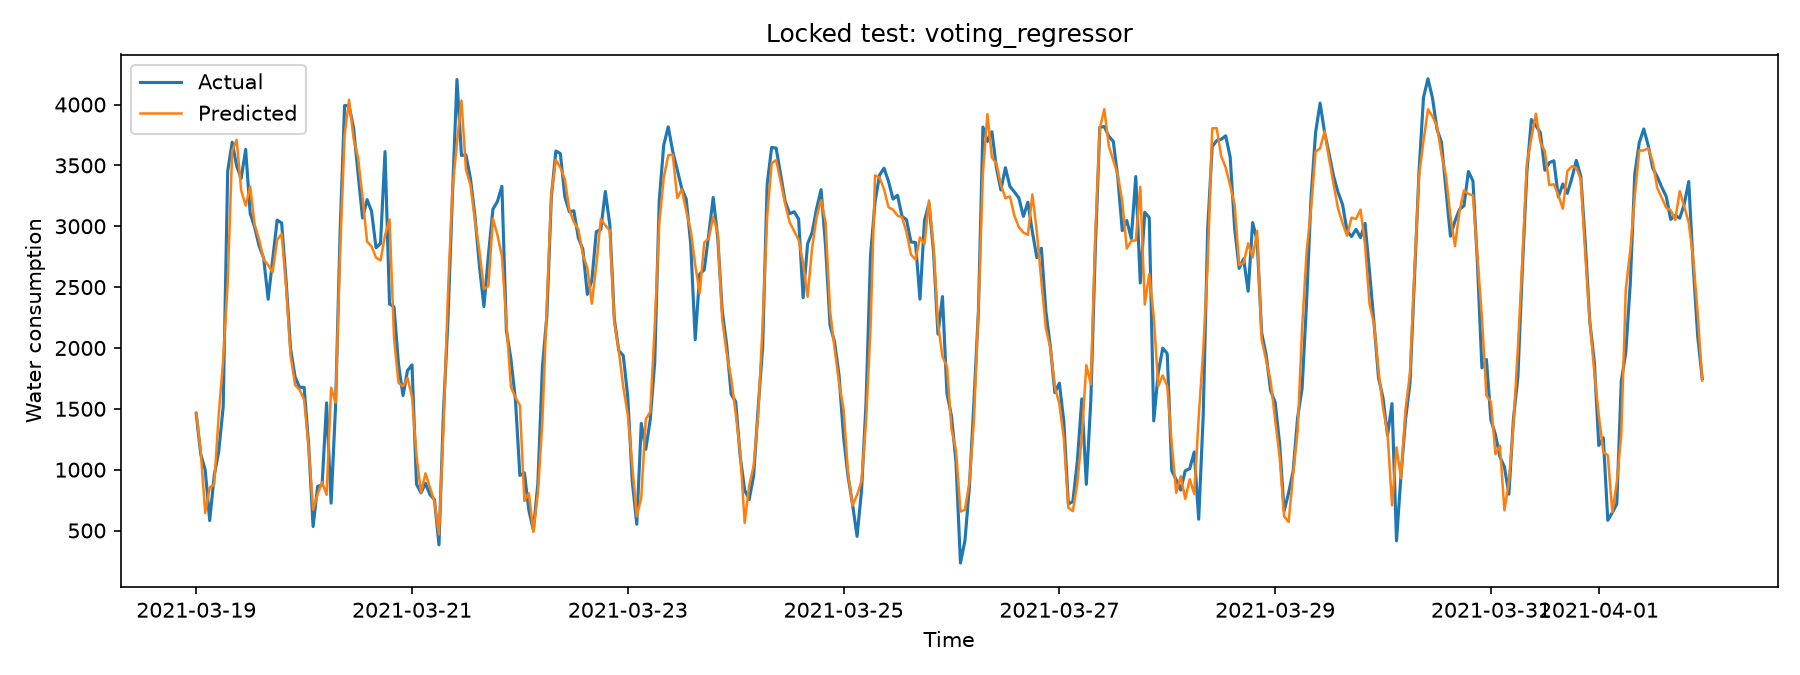

In [8]:
from IPython.display import Image, display
p = ROOT / 'artifacts/results/final_evaluation/locked_test_forecast.png'
display(Image(filename=str(p)))


## Interview explanation

**Problem:** one-hour-ahead operational water-demand forecasting.  
**Baseline:** persistence + simple ML.  
**Better:** leakage-safe engineered lags/calendar/weather with Bagging, boosting/XGBoost and Voting.  
**Optimal:** time-aware CV, Optuna for shortlisted ML, Keras Tuner for DL, then one locked-test evaluation.  

**Limitation:** target-hour weather was not treated as known. Only lagged observed weather was used; a production system would consume forecast weather.
